> **Note on reproducibility - Materials Project database**
>
> The MP-database filter queries the **live** Materials Project API each time the notebook
> is run. The MP database grows continuously as new compounds are computed and added.
>
> The paper reports **41** candidates after the MP filter. Running the notebook after the
> MP release v2026.04.13 yields **39**, because IrRhO4 (mp-3240494) was added to the
> Materials Project in that release. This causes all GNoME candidates with the element
> set {Ir, Rh, O} to be filtered out as no longer novel — two compounds are affected:
> IrRh5O12 (GNoME id: 33095629c4) and Ir(RhO3)2 (GNoME id: eae2b2cd97).


# Imports:

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ase.io import Trajectory
from ase.visualize import view
from pymatgen.io.ase import AseAtomsAdaptor
import seaborn as sns
import matplotlib.pyplot as plt
col_list = sns.color_palette("tab10", 100)

import tqdm

import os
from aq_gnome import (
    Data_Handler,
    plot_periodic_table_with_values, get_col_dict_for_atoms,
    Stable_Entries, Stability_Criteria, get_simplified_df,
    atoms_from_db, Compound_HHI_scores, sys_in_MP_db
)

# pHs = np.linspace(-2, 16, 19) # Data specific
# Us = np.linspace(-2, 4, 31) # Data specific

# Database setup:

In [22]:
# Define directory of data (can be left as None if the data folder is in 
# the package root):
dir_of_data = None

dh = Data_Handler(
# Whether to apply solid filter:
    solid_filter = False,  # <<<<<------------------- NOTE NOTE NOTE NOTE NOTE 
# Whether to use only GGA calculations (True), or include r2SCAN data via the MP-mixing scheme (False):
    gga_only = False,
# Path to data directory:
    path_to_data_directory = dir_of_data
    )

# Inclusion/exclusion of elements:

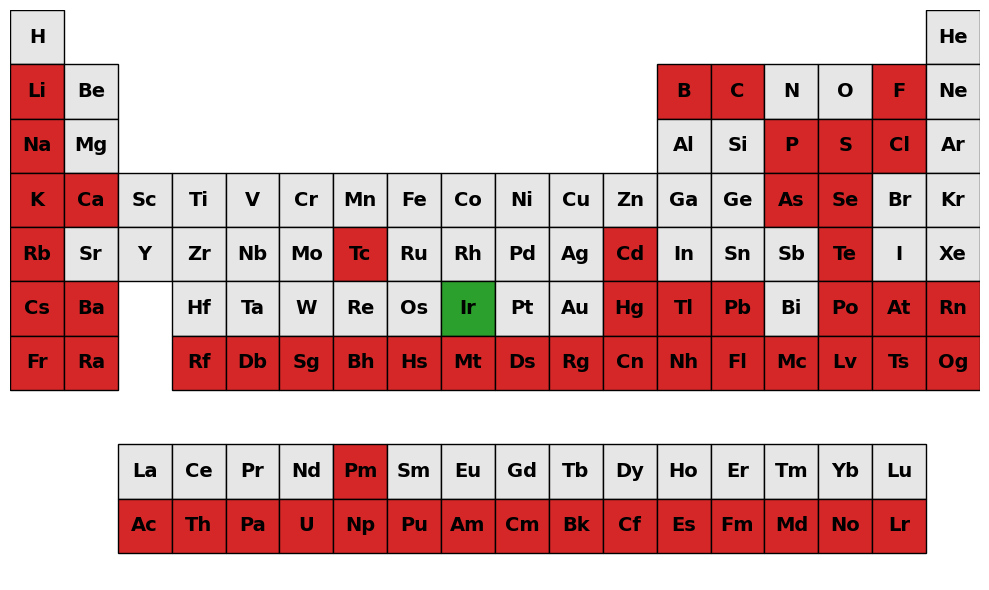

In [23]:
radioactive_elements = ['Tc',  'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs',
                        'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv',
                        'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np', 
                        'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md',
                        'No', 'Lr', 'Po', 'At', 'Rn'
                        ]
reactive_with_water_elements = ['Li', 'Na', 'K', 'Rb', 'Cs', 'Fr', 'Ca', 'Ba']

toxic_elements = ['Tl', 'Pb', 'As', 'Cd', 'Hg']

too_rare_elements = ['Be', 'Y', 'Nb', 'Rh', 'Pd', 'Te', 'Sb', 'Lu', 'Re',
                    'Os', 'Pt', 'Hg', 'Bi', 'La', 'Ce', 'Pr', 'Nd', 'Pm',
                    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
                    'Ru', 'Ir']


CMR = [
    'Be', 'B', 'Si', 'Sc', 'Ti', 'V', 'Co', 'Ga', 'Ge', 'Cr', 'Y', 'Nb', 
    'Ru', 'Rh', 'Pd', 'Sb', 'Lu', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt', 'Bi',
    'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd',
    'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb'
]

platinum_group = ['Ru', 'Rh', 'Pd', 'Os', 'Ir', 'Pt']


elements_to_exclude = radioactive_elements + toxic_elements + reactive_with_water_elements + ['F', 'Se', 'Te', 'B', 'P', 'S', 'Cl', 'C'] # + ['S', 'C', 'Cl', 'P', 'B', 'Bi']
 # + higly_concentrated_elements  # elements to discart
elements_whic_must_be_included = ['Ir']

plot_periodic_table_with_values(
    get_col_dict_for_atoms(elements_to_discard=elements_to_exclude, 
                           elements_to_include=elements_whic_must_be_included)
)

### Discarding materials based on element selection

In [24]:
dh.remove_entries_with_elements(elements_to_exclude)
dh.remove_entries_without_elements(elements_whic_must_be_included, True)

Number of entries removed: 283529 Number of entries left: 245442 which is 46.40% of total GNoME database
Removed all entries not containing all of the following elements: Ir .Number of entries removed: 203752 Number of entries left: 41690 which is 7.88% of total GNoME database


### pbx stability criteria

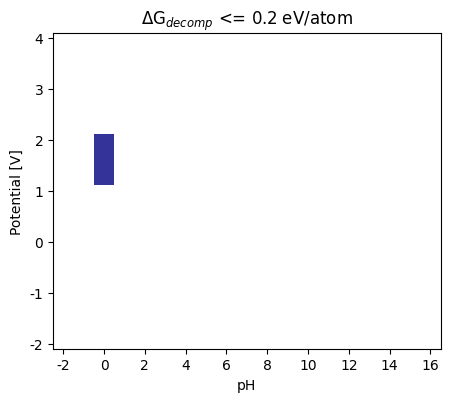

In [25]:
SCS = [Stability_Criteria(pHs=[0], Us=[1.2, 2], decomposition_threshold=0.2)
       # Stability_Criteria(pHs=0, Us=[1.2, 1.6], decomposition_threshold=0.05),
       # Stability_Criteria(pHs=[2, 5], Us=[0., 2], decomposition_threshold=1),
       ]

for sc in SCS:
    sc.visualize()

In [26]:
se = Stable_Entries(dh, SCS)
df_new = se.get_stable_df()

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


100%|██████████| 41690/41690 [00:22<00:00, 1869.63it/s]


Found 73 stable entries given the stability criteria.


In [17]:
# df = df[df["Disorder Probability"] < 0.2]
# df = df[~df['Reduced Formula'].apply(lambda x: '(SO4)' in x)]

# df = df[~df['Elements'].apply(lambda x: 'F' in x)]

df = se.get_stable_df()

# df = df[df['Dimensionality Cheon'] == '3D']
df = df[df['NSites'] < 40]
# df = df[df['Bandgap'] < .5]
df = df[df['average_HHI_P_excluding_O_H'] < 5000]
df = df[df['max_HHI_P'] < 9500]
# df = df[df['max_HHI_R'] < 6500]
# df = df[df['Disorder Probability'] < 0.5]

# df = get_simplified_df(df)
df = df.sort_values(by="Bandgap")
# df = df.sort_values(by="HHI_P_excluding_OHCNP")
print(len(df))

53


In [ ]:
df

> **Note:** This cell queries the live MP API. See the reproducibility note at the top
> of this notebook for the specific compound and MP release that changed the results.


In [10]:
simp = sys_in_MP_db(os.environ["MP_API_KEY"])

df = df[~df['Elements'].apply(lambda x: simp.in_db(x))]
print(len(df))
df

Retrieving ThermoDoc documents: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 350/350 [00:00<00:00, 763791.05it/s]
c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\GNoME_aqueous_stability\.venv\Lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
Retrieving ThermoDoc documents: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 393/393 [00:00<00:00, 2808111.54it/s]


39


,"max_dG_U[1.2,2]_pH0",Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
185981,0.08,Ag3Bi1Ir2O14Rh2,5a091b8756,Ag3BiIr2(RhO7)2,"[O, Rh, Ag, Ir, Bi]",22,267.4316,8.3627,2/m,C2/m,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_5a091b8756,GGA_5a091b8756,0.929380,1514.0,2336.0,3288.0,5550.0,5500.0,9100.0
468953,0.11,Ir3O12Pd1Zn2,e30f4d4add,Zn2Ir3PdO12,"[O, Zn, Pd, Ir]",18,199.4238,8.3757,mm2,Cmm2,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_e30f4d4add,r2S_e30f4d4add,0.896533,1606.0,2506.0,3817.0,6517.0,5500.0,9100.0
147692,0.07,Ir2Ni2O12Rh2,4768d23b8d,NiIrRhO6,"[O, Ni, Rh, Ir]",18,193.6227,7.7153,4mm,P4_2nm,...,gs://crystal-design/output/borg/round_2_mo_4/1...,GGA_4768d23b8d,r2S_4768d23b8d,0.893908,1411.0,2400.0,3233.0,6200.0,5500.0,9100.0
399035,0.20,Bi3In1Ir1O14Rh3,c11c222f68,InBi3IrRh3O14,"[O, Rh, In, Ir, Bi]",22,274.9004,8.8595,2/m,C2/m,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_c11c222f68,GGA_c11c222f68,0.916914,1877.0,2732.0,4288.0,6638.0,5500.0,9100.0
108635,0.09,Cu2Ir3O12Rh1,348673c0ba,Cu2Ir3RhO12,"[O, Cu, Rh, Ir]",18,194.2096,8.5386,mm2,Cmm2,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_348673c0ba,GGA_348673c0ba,0.894699,1606.0,2461.0,3817.0,6383.0,5500.0,9100.0
380620,0.19,Bi3Co1Ir1O14Rh3,b85a209e2b,CoBi3IrRh3O14,"[O, Co, Rh, Ir, Bi]",22,268.7730,8.7162,2/m,C2/m,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_b85a209e2b,GGA_b85a209e2b,0.926355,1868.0,2764.0,4262.0,6725.0,5500.0,9100.0
206003,0.06,Fe1Ir2O12Rh2Zn1,63bd4a9ff2,ZnFeIr2(RhO6)2,"[O, Fe, Zn, Rh, Ir]",18,197.0653,7.6131,mm2,Cmm2,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_63bd4a9ff2,GGA_63bd4a9ff2,0.924921,1522.0,2417.0,3567.0,6250.0,5500.0,9100.0
307895,0.09,Fe1Ir2O12Rh3,951e8c17c9,FeIr2(RhO4)3,"[O, Fe, Rh, Ir]",18,196.2841,7.9606,mm2,Cmm2,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_951e8c17c9,r2S_951e8c17c9,0.938736,1611.0,2756.0,3833.0,7267.0,5500.0,9100.0
148320,0.11,Ga1Ir2O12Rh3,47b687b292,GaIr2(RhO4)3,"[O, Ga, Rh, Ir]",18,195.5129,8.1099,mm2,Cmm2,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_47b687b292,r2S_47b687b292,0.935238,1783.0,2783.0,4350.0,7350.0,5500.0,9100.0
472092,0.16,Cu2Ir4O12,e49083a195,Cu(IrO3)2,"[O, Cu, Ir]",18,193.6095,9.3311,mmm,Pnnm,...,gs://crystal-design/output/borg/round_2_mo_3/1...,GGA_e49083a195,r2S_e49083a195,0.113992,1733.0,2522.0,4200.0,6567.0,5500.0,9100.0


In [ ]:
# old_df = pd.read_csv('Ir_sf_False_low_HHI_v2.csv')

# found = 0
# for i, row in old_df.iterrows():
#     if not ((df['MaterialId'] == row['MaterialId']).any()):
#         print(row['MaterialId'])
#     else:
#         found += 1

# print(f'Found {found} out of {len(old_df)} in new selection.')

# found = 0
# for i, row in df.iterrows():
#     if not ((old_df['MaterialId'] == row['MaterialId']).any()):
#         print(row['MaterialId'])
#     else:
#         found += 1

# print(f'Found {found} out of {len(df)} in old selection.')

Found 45 out of 45 in new selection.
Found 45 out of 45 in old selection.


## Below, other sorting / lokking up in ICSD

In [11]:
# Convert each list Ã¢â€ â€™ frozenset, then get unique ones
unique_sets = set(frozenset(lst) for lst in arr)

# Optional: convert back to normal sets if you want
unique_sets = [set(s) for s in unique_sets]

print(len(arr), 'to:', len(unique_sets))

45 to: 27


In [12]:
unique_sets

[{'Ir', 'Ni', 'O', 'Rh'},
 {'Bi', 'Ir', 'O', 'Rh', 'Zn'},
 {'Ag', 'Ir', 'Nd', 'O', 'Rh'},
 {'Bi', 'Cu', 'Ir', 'O', 'Rh'},
 {'Cu', 'Ir', 'O'},
 {'Bi', 'Ir', 'Mn', 'O'},
 {'Ga', 'Ir', 'O', 'Rh'},
 {'Fe', 'Ga', 'Ir', 'O'},
 {'Fe', 'Ir', 'O', 'Pd'},
 {'Ag', 'Bi', 'Ir', 'La', 'O', 'Rh'},
 {'Bi', 'Cu', 'Ir', 'O'},
 {'Ir', 'O', 'Rh', 'Zn'},
 {'Ag', 'Bi', 'Co', 'Ir', 'O'},
 {'Fe', 'Ir', 'O', 'Sb'},
 {'Bi', 'Co', 'Ir', 'O', 'Rh'},
 {'Ag', 'Ir', 'O', 'Rh', 'Y'},
 {'Ir', 'O', 'Pd'},
 {'Ir', 'O', 'Rh'},
 {'Ag', 'Bi', 'Ir', 'O', 'Rh'},
 {'Cu', 'Ir', 'O', 'Pd'},
 {'Bi', 'In', 'Ir', 'Mg', 'O', 'Rh'},
 {'Ir', 'O', 'Pd', 'Zn'},
 {'Fe', 'Ir', 'O', 'Rh'},
 {'Cu', 'Ir', 'O', 'Rh'},
 {'Fe', 'Ir', 'O', 'Rh', 'Zn'},
 {'Bi', 'In', 'Ir', 'O', 'Rh'},
 {'Cu', 'Ir', 'O', 'Sb'}]


Exists in ICSD:
{'Cu', 'Ir', 'O'} 
{'Ir', 'O', 'Pd'}

In [24]:
import math

def angle_between_vectors(v1, v2):
    # Dot product
    dot = sum(a * b for a, b in zip(v1, v2))
    
    # Magnitudes
    mag_v1 = math.sqrt(sum(a * a for a in v1))
    mag_v2 = math.sqrt(sum(b * b for b in v2))
    
    # Guard against zero-length vectors
    if mag_v1 == 0 or mag_v2 == 0:
        raise ValueError("Cannot compute angle with zero-length vector")
    
    # Angle in radians
    cos_theta = dot / (mag_v1 * mag_v2)
    
    # Numerical safety
    cos_theta = max(-1.0, min(1.0, cos_theta))
    
    return math.acos(cos_theta)  # radians


In [ ]:
df = pd.read_csv('Ir_sf_False_low_HHI_v2.csv')

retrive_atoms = atoms_from_db()
atoms_list = retrive_atoms.get_atoms_objects_from_df(df)

In [46]:

all_angle_sets = []
for atoms in atoms_list:
    cell = atoms.cell
    v1 = cell[0]
    v2 = cell[1]
    v3 = cell[2]

    vs = [v1, v2, v3]

    angles = []

    for v1 in vs:
        for v2 in vs:
            if not np.array_equal(v1, v2):
                angle_rad = angle_between_vectors(v1, v2)
                angle_deg = math.degrees(angle_rad)
                angles.append(angle_deg)

    all_angle_sets.append(set(np.round(angles, -1)))

un_angle_sets = list(set(frozenset(s) for s in all_angle_sets))
un_angle_sets

df['angle_groups'] = None

j = 0
for i, row in df.iterrows():

    atoms = atoms_list[j]
    j += 1
    cell = atoms.cell
    v1 = cell[0]
    v2 = cell[1]
    v3 = cell[2]

    vs = [v1, v2, v3]

    angles = []
    for v1 in vs:
        for v2 in vs:
            if not np.array_equal(v1, v2):
                angle_rad = angle_between_vectors(v1, v2)
                angle_deg = math.degrees(angle_rad)
                angles.append(angle_deg)

    angle_set = set(np.round(angles, -1))

    for k, un_set in enumerate(un_angle_sets):
        if angle_set == set(un_set):
            df.at[i, 'angle_groups'] = k


view(
retrive_atoms.get_atoms_objects_from_df(df.sort_values(by=['angle_groups', 'NSites']))
)


  0%|          | 0/45 [00:00<?, ?it/s]

100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 45/45 [00:04<00:00,  9.37it/s]


<Popen: returncode: None args: ['c:\\Users\\matnis\\OneDrive - Danmarks Tekn...>

In [50]:
atoms_list = retrive_atoms.get_atoms_objects_from_df(df.sort_values(by=['angle_groups', 'NSites']))

traj_out = Trajectory('Ir_sf_False_low_HHI_v2.traj', 'w')

for atoms in atoms_list:  
    traj_out.write(atoms)
traj_out.close()



100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 45/45 [00:04<00:00,  9.61it/s]


In [2]:
# df.sort_values(by=['angle_groups', 'NSites'])

100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 45/45 [00:03<00:00, 12.59it/s]


In [23]:
atoms_list[0].cell

Cell([[6.2498852406234136, 0.0, 3.7062443226837405], [2.127619423734195, 5.876589245270222, 3.7062446493736805], [0.0, 0.0, 7.28140791]])

In [ ]:
retrive_atoms = atoms_from_db()



100%|Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†Ã¢â€“Ë†| 45/45 [00:03<00:00, 12.20it/s]


<Popen: returncode: None args: ['c:\\Users\\matnis\\OneDrive - Danmarks Tekn...>

In [48]:
df.sort_values(by=['angle_groups', 'NSites']).to_csv('Ir_sf_False_low_HHI_v2.csv', index=False)

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


In [18]:
U_interval = np.linspace(-2, 4, 31) # Data specific 
pH_interval = np.linspace(-2, 16, 19) # Data specific

np.where(pH_interval == 0)

(array([2]),)

In [1]:
# working_df = pd.read_csv('Ir_sf_False_low_HHI_v2.csv')
# se = Stable_Entries(dh, [])

# working_df

In [8]:
Us = np.linspace(-2, 4, 31) # Data specific 
Us[16:21]

array([1.2, 1.4, 1.6, 1.8, 2. ])

In [9]:
working_df['max G'] = None
for i, row in working_df.iterrows():
    working_df.at[i, 'max G'] = np.max(se.get_decom_G(row)[16:21,2])

In [10]:
working_df = working_df.drop(columns=['Point Group', 'Composition', 'Elements', 'Volume', 'Density', 'Space Group', 'Space Group Number',
                          'gga_only_pbx_save_id', 'mixed_pbx_save_id', 'average_HHI_P', 'max_HHI_P', 'average_HHI_R', 
                          'average_HHI_R_excluding_OHCNPS', 'max_HHI_R', 'angle_groups', 'Crystal System', 'Uncorrected Energy', 'Corrected Energy', 
                          'Formation Energy Per Atom', 'Decomposition Energy Per Atom', 'Dimensionality Cheon', 'Is Train', 'Bandgap', 'Decomposition Energy Per Atom All',
                          'Decomposition Energy Per Atom Relative', 'Decomposition Energy Per Atom MP', 'Decomposition Energy Per Atom MP OQMD', 'Data Directory'])
working_df = working_df[['Reduced Formula', 'max G', 'average_HHI_P_excluding_OHCNPS', 'Disorder Probability']]

In [ ]:
# pd.DataFrame.to_csv(working_df, 'Ir_for_PUBLICATION.csv')